In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('../data/Music_Info.csv')

In [3]:
df.head(5)

,track_id,name,artist,spotify_preview_url,spotify_id,tags,genre,year,duration_ms,danceability,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,TRIOREW128F424EAF0,Mr. Brightside,The Killers,https://p.scdn.co/mp3-preview/4d26180e6961fd46...,09ZQ5TmUG8TSL56n0knqrj,"rock, alternative, indie, alternative_rock, in...",NaN,2004,222200,0.355,...,1,-4.360,1,0.0746,0.001190,0.000000,0.0971,0.240,148.114,4
1,TRRIVDJ128F429B0E8,Wonderwall,Oasis,https://p.scdn.co/mp3-preview/d012e536916c927b...,06UfBBDISthj1ZJAtX4xjj,"rock, alternative, indie, pop, alternative_roc...",NaN,2006,258613,0.409,...,2,-4.373,1,0.0336,0.000807,0.000000,0.2070,0.651,174.426,4
2,TROUVHL128F426C441,Come as You Are,Nirvana,https://p.scdn.co/mp3-preview/a1c11bb1cb231031...,0keNu0t0tqsWtExGM3nT1D,"rock, alternative, alternative_rock, 90s, grunge",RnB,1991,218920,0.508,...,4,-5.783,0,0.0400,0.000175,0.000459,0.0878,0.543,120.012,4
3,TRUEIND128F93038C4,Take Me Out,Franz Ferdinand,https://p.scdn.co/mp3-preview/399c401370438be4...,0ancVQ9wEcHVd0RrGICTE4,"rock, alternative, indie, alternative_rock, in...",NaN,2004,237026,0.279,...,9,-8.851,1,0.0371,0.000389,0.000655,0.1330,0.490,104.560,4
4,TRLNZBD128F935E4D8,Creep,Radiohead,https://p.scdn.co/mp3-preview/e7eb60e9466bc3a2...,01QoK9DA7VTeTSE3MNzp4I,"rock, alternative, indie, alternative_rock, in...",RnB,2008,238640,0.515,...,7,-9.935,1,0.0369,0.010200,0.000141,0.1290,0.104,91.841,4


In [4]:
df.shape

(50683, 21)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50683 entries, 0 to 50682
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   track_id             50683 non-null  object 
 1   name                 50683 non-null  object 
 2   artist               50683 non-null  object 
 3   spotify_preview_url  50683 non-null  object 
 4   spotify_id           50683 non-null  object 
 5   tags                 49556 non-null  object 
 6   genre                22348 non-null  object 
 7   year                 50683 non-null  int64  
 8   duration_ms          50683 non-null  int64  
 9   danceability         50683 non-null  float64
 10  energy               50683 non-null  float64
 11  key                  50683 non-null  int64  
 12  loudness             50683 non-null  float64
 13  mode                 50683 non-null  int64  
 14  speechiness          50683 non-null  float64
 15  acousticness         50683 non-null 

#### missing values in tags and genre columns

In [6]:
df.isna().sum()         

track_id                   0
name                       0
artist                     0
spotify_preview_url        0
spotify_id                 0
tags                    1127
genre                  28335
year                       0
duration_ms                0
danceability               0
energy                     0
key                        0
loudness                   0
mode                       0
speechiness                0
acousticness               0
instrumentalness           0
liveness                   0
valence                    0
tempo                      0
time_signature             0
dtype: int64

<Axes: >

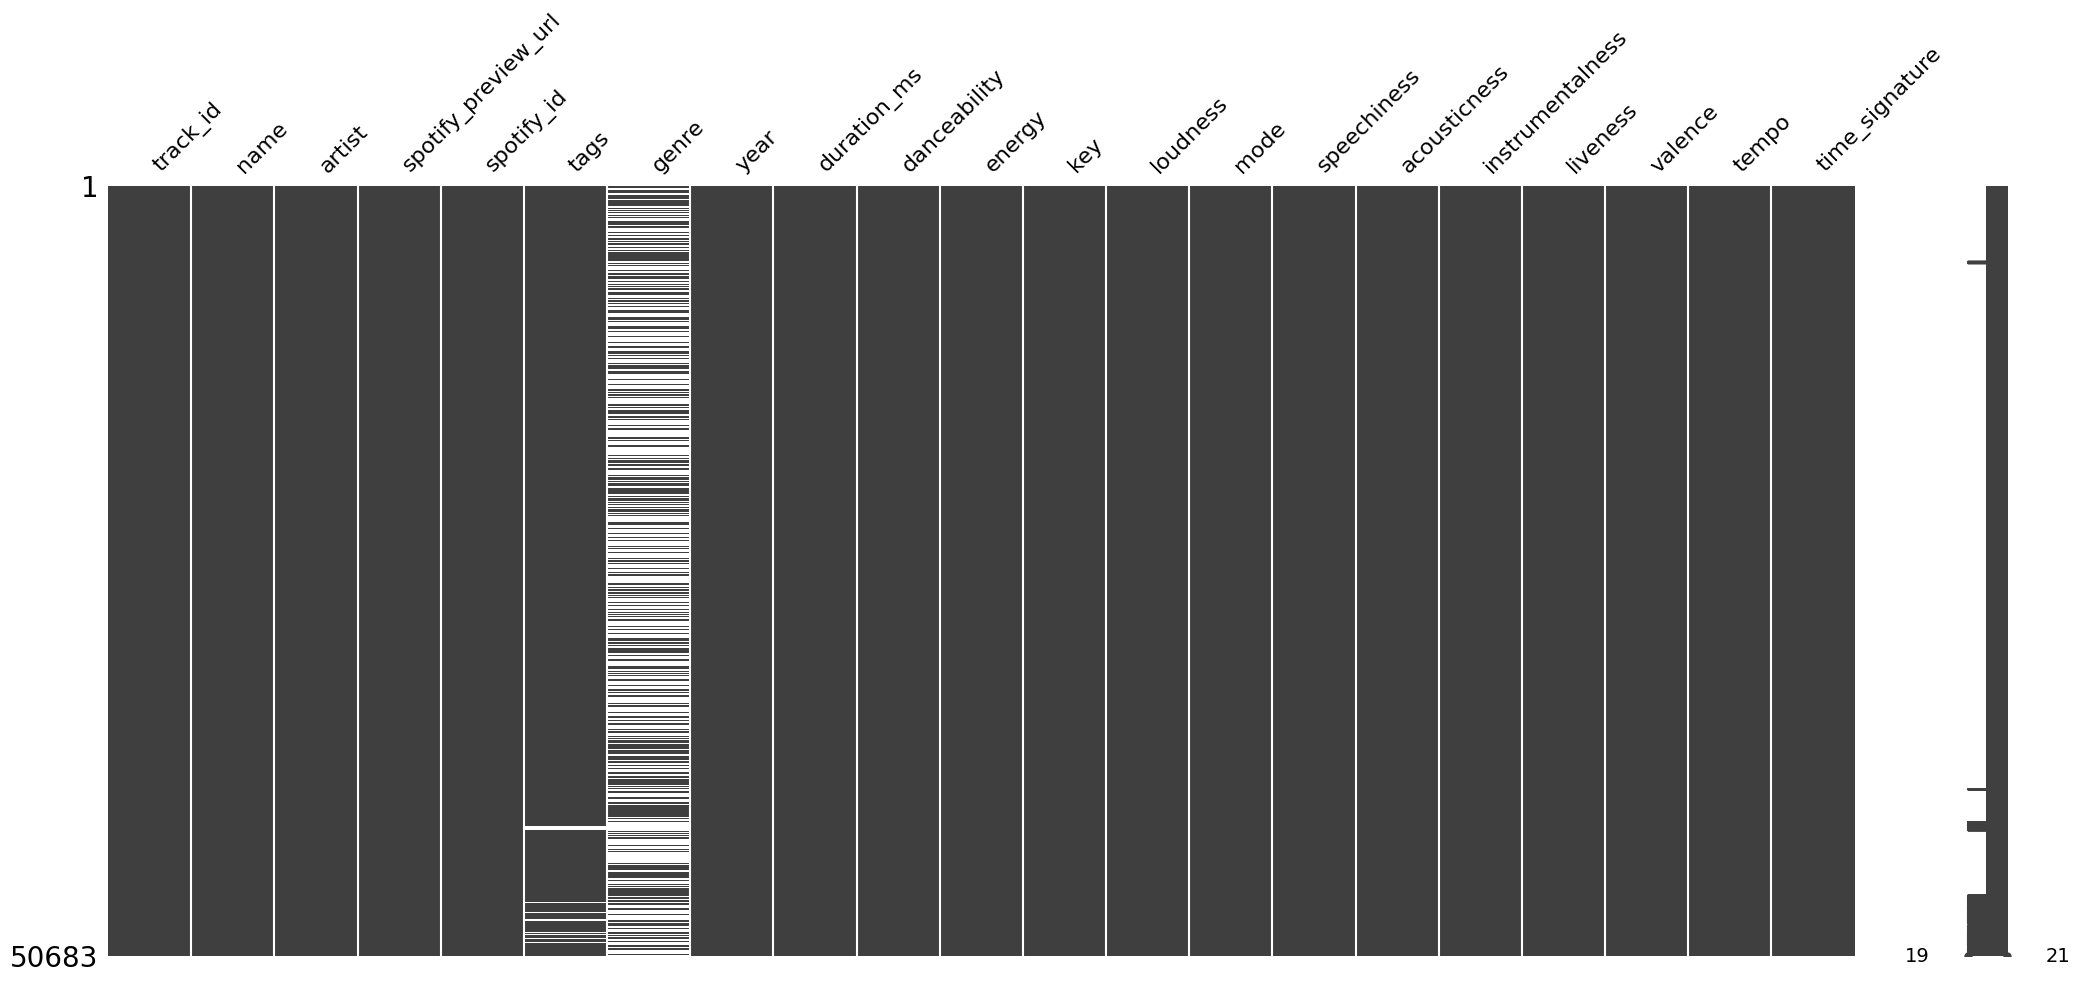

In [7]:
import missingno as msno
msno.matrix(df)

#### missing values in genere column is randon, there is no as such pattern of missingness in the column

In [8]:
df.isna().sum()/df.shape[0] * 100

track_id                0.000000
name                    0.000000
artist                  0.000000
spotify_preview_url     0.000000
spotify_id              0.000000
tags                    2.223625
genre                  55.906320
year                    0.000000
duration_ms             0.000000
danceability            0.000000
energy                  0.000000
key                     0.000000
loudness                0.000000
mode                    0.000000
speechiness             0.000000
acousticness            0.000000
instrumentalness        0.000000
liveness                0.000000
valence                 0.000000
tempo                   0.000000
time_signature          0.000000
dtype: float64

### 2.22 percent out of total values is missing in tags column whereas 55.90 percent out of total values is missing in genre column.

In [9]:
df[df.assign(name = df['name'].str.lower()).duplicated(subset='name')].sort_values('name')

,track_id,name,artist,spotify_preview_url,spotify_id,tags,genre,year,duration_ms,danceability,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
34480,TRKKZMK128F4257579,3 am,Liv Kristine,https://p.scdn.co/mp3-preview/7d91eb9292e9c7c7...,1TgsnkiolcBhQssCR37JXx,"female_vocalists, power_metal, gothic_metal, g...",NaN,2005,302880,0.516,...,0,-6.038,0,0.0390,0.152000,0.005970,0.1070,0.4410,78.009,4
43800,TRPWOAS128E0781045,3am,Halsey,https://p.scdn.co/mp3-preview/afe9a1433dfe18b6...,1OfLNb6dQ9dra1B58iT9Ex,pop_rock,NaN,2020,234858,0.385,...,0,-4.604,0,0.0795,0.009060,0.000000,0.5790,0.5380,189.760,4
38764,TRXEFAP128F9321AB7,4th Of July,Aimee Mann,https://p.scdn.co/mp3-preview/fdda379ed8d895e0...,2fW1zQeo6QEhZviaudZvBu,"rock, female_vocalists, singer_songwriter, gui...",NaN,2004,209173,0.432,...,5,-10.926,1,0.0325,0.854000,0.000022,0.9830,0.2630,132.694,3
9974,TRGZNPZ128F14939EB,A Day In The Life,Wes Montgomery,https://p.scdn.co/mp3-preview/7c68ec631b614556...,0GxCysYaqNYs57mP7vFaBR,"jazz, 60s, cover",Rock,2009,350333,0.483,...,9,-10.725,0,0.0263,0.571000,0.366000,0.0922,0.3710,98.507,4
46102,TRSAJSN128F4249498,A Place in the Sun,Lit,https://p.scdn.co/mp3-preview/2807fdf8fd24ad22...,10vZsPb0c1gcNRoxP7dGKB,"rock, alternative_rock, ska",Rock,1999,260360,0.426,...,11,-3.505,1,0.0862,0.000056,0.022000,0.1770,0.4030,160.665,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48518,TRVDTSL128F425A866,the Love Song,K-OS,https://p.scdn.co/mp3-preview/a1f080c9cbcb799b...,0D01CHXz6zBaJOYWVY3cuF,hip_hop,Rap,2004,256946,0.668,...,5,-6.867,0,0.1080,0.090800,0.000002,0.2870,0.6370,89.078,4
40027,TRHLKXB128F9330FB4,the waves,All My Faith Lost ...,https://p.scdn.co/mp3-preview/f295a6202baf763e...,3yRACVTfhDtcgdlJBmAC2k,"gothic, dark_ambient",NaN,2007,271133,0.230,...,9,-13.877,0,0.0339,0.929000,0.897000,0.1290,0.0671,75.432,3
39171,TRADNPA12903CBDADE,time to go,Wax Tailor,https://p.scdn.co/mp3-preview/c7b4c61ab5112be4...,0IE64wOdOdeGXSOFjbHjRP,"indie, indie_rock, idm",NaN,2012,209920,0.671,...,7,-6.162,0,0.0855,0.199000,0.007400,0.3600,0.3620,100.014,4
43632,TRAZKLR128F92C6584,under the sun,Do As Infinity,https://p.scdn.co/mp3-preview/6f7a1ff40803a831...,6AWpZWTZkuzCctkgh1mtbG,"japanese, j_pop",NaN,2009,241241,0.315,...,2,-1.206,0,0.0950,0.013100,0.810000,0.2970,0.1840,129.809,4


### 815 entries are dublicated in the dataset, i mean 815 songs has the same name but diffrent artist and other features which means the songs are diffrent. But the combination of year,duration is same for the actual duplicate songs and diffrent for some entries which has same song name but diffrent artist. 

In [10]:
df.duplicated(subset='spotify_id').sum()

np.int64(9)

In [11]:
df.duplicated(subset=['spotify_id' , 'year' , 'duration_ms']).sum()

np.int64(9)

### Intrestingly,spotify_id is same for the duplicate songs when the songs are actually duplicate as all the features are also matching. So we can drop the duplicate songs based on spotify_id column.We have only 9 duplicate songs in the dataset which are actual duplicate songs and we can drop them based on spotify_id column.

In [12]:
df.drop_duplicates(subset=['spotify_id' , 'year' , 'duration_ms'], inplace=True)

In [13]:
df.duplicated(subset=['spotify_id' , 'year' , 'duration_ms']).sum()

np.int64(0)

In [14]:
categorical_features = df.select_dtypes(include=['object']).columns
categorical_features

Index(['track_id', 'name', 'artist', 'spotify_preview_url', 'spotify_id',
       'tags', 'genre'],
      dtype='object')

In [15]:
def categorical_analysis(df,feature_name,k_artist = 15):

    for feature in feature_name:
        print(f"Feature: {feature}")
        print(f"Number of unique values: {df[feature].str.lower().nunique()}")
        if feature in ['artist','genre']:
            print(f"Top {k_artist} most frequent values:")
            print(df[feature].str.lower().value_counts().head(k_artist))
        if feature == 'genre':
            print(f"unique values in genre column: {df[feature].dropna().nunique()}")

In [16]:
categorical_analysis(df,categorical_features)

Feature: track_id
Number of unique values: 50674
Feature: name
Number of unique values: 49860
Feature: artist
Number of unique values: 8317
Top 15 most frequent values:
artist
the rolling stones    132
radiohead             110
autechre              105
tom waits             100
bob dylan              98
the cure               94
metallica              85
johnny cash            84
nine inch nails        83
sonic youth            81
iron maiden            76
in flames              76
elliott smith          76
mogwai                 75
boards of canada       75
Name: count, dtype: int64
Feature: spotify_preview_url
Number of unique values: 50620
Feature: spotify_id
Number of unique values: 50674
Feature: tags
Number of unique values: 20054
Feature: genre
Number of unique values: 15
Top 15 most frequent values:
genre
rock          9965
electronic    3710
metal         2516
pop           1145
rap            820
jazz           793
rnb            696
reggae         691
country        607
pun

In [17]:
gener_group = df.groupby("genre")

gener_group[['genre','tags']].sample()

,genre,tags
17744,Blues,"electronic, 80s, new_wave, synthpop"
33041,Country,country
47026,Electronic,electronic
34842,Folk,"folk, acoustic, male_vocalists"
32538,Jazz,"60s, oldies"
49517,Latin,female_vocalists
26495,Metal,progressive_metal
11404,New Age,"ambient, chillout, new_age"
9252,Pop,"jazz, male_vocalists, oldies"
46466,Punk,"punk, ska"


### we cannot figureout genre using tags column

In [18]:
df.loc[df.loc[:,'name'].str.contains("[^\d\w\s.?!':-_(){},\.#-&/-]")].shape

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
C:\Users\KIIT0001\AppData\Local\Temp\ipykernel_30072\2990401346.py:1: SyntaxWarning: invalid escape sequence '\d'
  df.loc[df.loc[:,'name'].str.contains("[^\d\w\s.?!':-_(){},\.#-&/-]")].shape


(39, 21)

#### some of the names of the songs are not in english. 39 songs name are in some other language where some are in chinies some contain numbers and symbols like + _* and so on.

In [19]:
df.loc[df.loc[:,'artist'].str.contains("[^\d\w\s.?!':-_(){},\.#-&/-]")].sort_values('artist').sample(5)

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
C:\Users\KIIT0001\AppData\Local\Temp\ipykernel_30072\1568789906.py:1: SyntaxWarning: invalid escape sequence '\d'
  df.loc[df.loc[:,'artist'].str.contains("[^\d\w\s.?!':-_(){},\.#-&/-]")].sort_values('artist').sample(5)


,track_id,name,artist,spotify_preview_url,spotify_id,tags,genre,year,duration_ms,danceability,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
50183,TRXCYNS128F934BD93,The Game Is Over,*NSYNC,https://p.scdn.co/mp3-preview/cbae1d3df1cc8797...,54mxSb8VlMvj1QB2ryB9Rd,pop,NaN,2001,205466,0.727,...,4,-4.382,0,0.0884,0.03700,0.000000,0.3950,0.847,93.022,4
14977,TRXMUUB128F9309C5F,Yeah You,N*E*R*D,https://p.scdn.co/mp3-preview/54445c0c837cbb4a...,0oDb9mzuPm49lPA7eqiusj,"alternative, hip_hop, funk, rnb, chill",NaN,2008,245586,0.872,...,3,-4.886,0,0.0609,0.04500,0.000004,0.0704,0.907,113.014,4
25801,TRMIJFJ128F92E4322,Feeling Fine,L'Arc~en~Ciel,https://p.scdn.co/mp3-preview/0328f852ea690993...,1ZP6q6dIr4UWWFNN8zE6dM,japanese,NaN,2004,256933,0.485,...,2,-3.164,1,0.0429,0.00464,0.000007,0.3880,0.833,145.075,4
25806,TRBDBAO128F9306B96,ALONE EN LA VIDA,L'Arc~en~Ciel,https://p.scdn.co/mp3-preview/51e55caab6f0111e...,1RxDFC0T1i9xLu8gZaTWdq,japanese,NaN,2007,312160,0.485,...,9,-4.277,0,0.0326,0.06560,0.001740,0.2370,0.591,100.043,4
30418,TRDBRRN128F92F1AE3,Nah Mean,"Nas & Damian ""Jr. Gong"" Marley",https://p.scdn.co/mp3-preview/06689564d268f828...,12YgraSMOtLaJVXPHhPlPI,"hip_hop, reggae",NaN,2010,247053,0.591,...,10,-1.642,0,0.1610,0.02620,0.000000,0.1190,0.618,94.128,4


#### 91 artist names are unusual. some have numbers, some are combination of characters which is not making sense at all but this will not be issue as we are gonna encode then

In [20]:
all_tags = []

for tags in df['tags'].dropna().str.replace(" ","").str.split(","):
    all_tags.extend(tags)

In [21]:
len(set(all_tags))

100

In [22]:
df.loc[:,'tags'].dropna().str.split(",").explode().str.strip().unique()

array(['rock', 'alternative', 'indie', 'alternative_rock', 'indie_rock',
       '00s', 'pop', 'british', '90s', 'love', 'britpop', 'grunge',
       'piano', 'beautiful', 'mellow', 'chillout', 'funk', 'electronic',
       'dance', 'hip_hop', 'trip_hop', 'metal', 'hard_rock', 'nu_metal',
       'progressive_rock', 'classic_rock', '80s', '70s', 'experimental',
       'soundtrack', 'female_vocalists', 'heavy_metal', 'rap', '60s',
       'post_punk', 'pop_rock', 'punk', 'punk_rock', 'acoustic', 'emo',
       'new_wave', 'chill', 'indie_pop', 'gothic_metal', 'gothic',
       'thrash_metal', 'folk', 'singer_songwriter', 'country', 'cover',
       'blues_rock', 'psychedelic', 'psychedelic_rock', 'guitar',
       'american', 'ska', 'ambient', 'blues', 'oldies', 'french',
       'male_vocalists', 'reggae', 'instrumental', 'jazz', 'avant_garde',
       'industrial', 'german', 'synthpop', 'hardcore', 'metalcore',
       'screamo', 'post_rock', 'swedish', 'doom_metal', 'power_metal',
       'rnb', 

### we have 100 unique tags

In [23]:
integer_col = df.select_dtypes(include = 'int').columns

In [24]:
integer_col

Index(['year', 'duration_ms', 'key', 'mode', 'time_signature'], dtype='object')

In [25]:
df.head()

,track_id,name,artist,spotify_preview_url,spotify_id,tags,genre,year,duration_ms,danceability,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,TRIOREW128F424EAF0,Mr. Brightside,The Killers,https://p.scdn.co/mp3-preview/4d26180e6961fd46...,09ZQ5TmUG8TSL56n0knqrj,"rock, alternative, indie, alternative_rock, in...",NaN,2004,222200,0.355,...,1,-4.360,1,0.0746,0.001190,0.000000,0.0971,0.240,148.114,4
1,TRRIVDJ128F429B0E8,Wonderwall,Oasis,https://p.scdn.co/mp3-preview/d012e536916c927b...,06UfBBDISthj1ZJAtX4xjj,"rock, alternative, indie, pop, alternative_roc...",NaN,2006,258613,0.409,...,2,-4.373,1,0.0336,0.000807,0.000000,0.2070,0.651,174.426,4
2,TROUVHL128F426C441,Come as You Are,Nirvana,https://p.scdn.co/mp3-preview/a1c11bb1cb231031...,0keNu0t0tqsWtExGM3nT1D,"rock, alternative, alternative_rock, 90s, grunge",RnB,1991,218920,0.508,...,4,-5.783,0,0.0400,0.000175,0.000459,0.0878,0.543,120.012,4
3,TRUEIND128F93038C4,Take Me Out,Franz Ferdinand,https://p.scdn.co/mp3-preview/399c401370438be4...,0ancVQ9wEcHVd0RrGICTE4,"rock, alternative, indie, alternative_rock, in...",NaN,2004,237026,0.279,...,9,-8.851,1,0.0371,0.000389,0.000655,0.1330,0.490,104.560,4
4,TRLNZBD128F935E4D8,Creep,Radiohead,https://p.scdn.co/mp3-preview/e7eb60e9466bc3a2...,01QoK9DA7VTeTSE3MNzp4I,"rock, alternative, indie, alternative_rock, in...",RnB,2008,238640,0.515,...,7,-9.935,1,0.0369,0.010200,0.000141,0.1290,0.104,91.841,4


In [26]:
df[integer_col]

,year,duration_ms,key,mode,time_signature
0,2004,222200,1,1,4
1,2006,258613,2,1,4
2,1991,218920,4,0,4
3,2004,237026,9,1,4
4,2008,238640,7,1,4
...,...,...,...,...,...
50678,2008,273440,6,0,4
50679,2004,275133,0,1,4
50680,2014,254826,10,0,4
50681,2008,243293,4,0,4


In [27]:
df[integer_col].describe()

,year,duration_ms,key,mode,time_signature
count,50674.000000,5.067400e+04,50674.000000,50674.000000,50674.000000
mean,2004.017109,2.511536e+05,5.312507,0.631073,3.898153
std,8.860497,1.075892e+05,3.567967,0.482519,0.419686
min,1900.000000,1.439000e+03,0.000000,0.000000,0.000000
25%,2001.000000,1.927330e+05,2.000000,0.000000,4.000000
50%,2006.000000,2.349330e+05,5.000000,1.000000,4.000000
75%,2009.000000,2.881828e+05,9.000000,1.000000,4.000000
max,2022.000000,3.816373e+06,11.000000,1.000000,5.000000


In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: xlabel='year', ylabel='Count'>

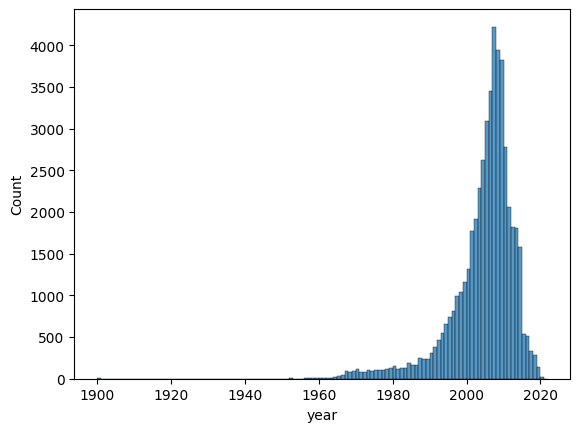

In [29]:
sns.histplot(df , x = 'year' , bins = df['year'].max()-df['year'].min())

In [30]:
df.loc[:,'year'].value_counts().head(5)

year
2007    4221
2008    3947
2009    3827
2006    3453
2005    3085
Name: count, dtype: int64

In [31]:
df.columns

Index(['track_id', 'name', 'artist', 'spotify_preview_url', 'spotify_id',
       'tags', 'genre', 'year', 'duration_ms', 'danceability', 'energy', 'key',
       'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness',
       'liveness', 'valence', 'tempo', 'time_signature'],
      dtype='object')

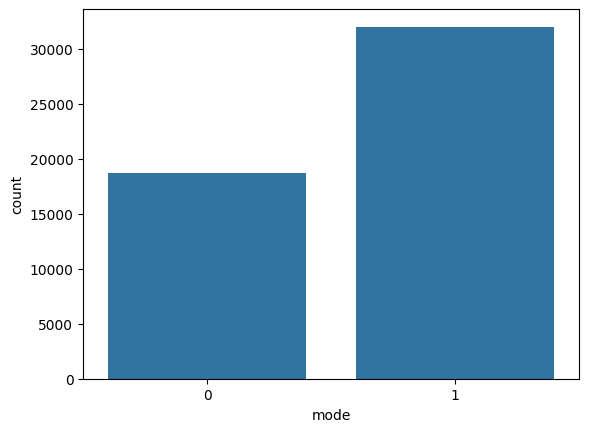

In [33]:
sns.countplot(df , x = 'mode')
plt.show()

In [35]:
df['time_signature'].unique()

array([4, 3, 5, 1, 0])

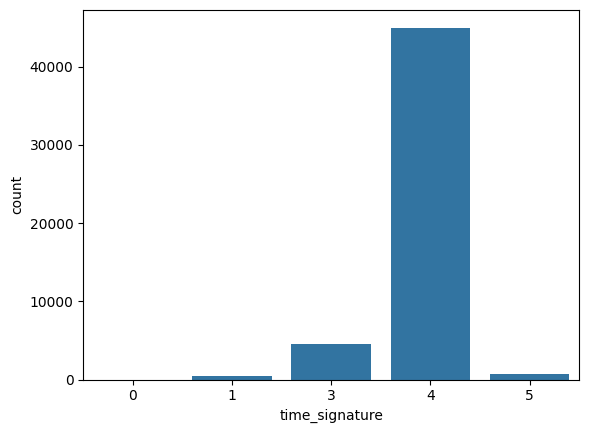

In [37]:
sns.countplot(df, x = 'time_signature')
plt.show()

In [38]:
time_duration_mins = df['duration_ms'].div(1000).div(60)

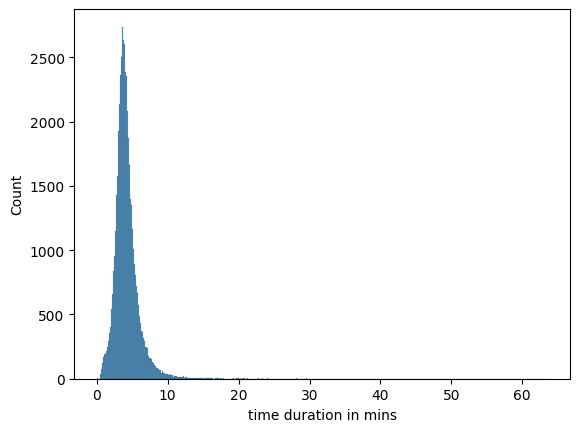

In [40]:
sns.histplot(time_duration_mins)
plt.xlabel("time duration in mins")
plt.show()

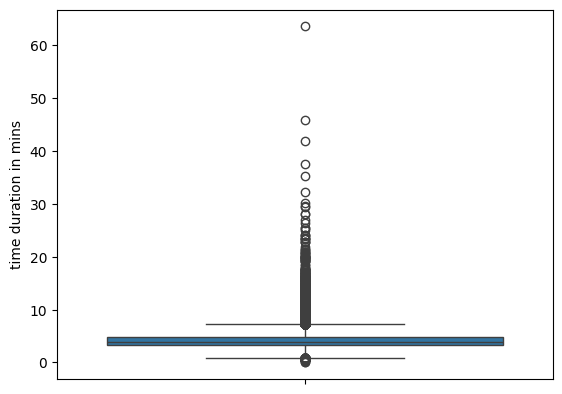

In [41]:
sns.boxplot(time_duration_mins)
plt.ylabel("time duration in mins")
plt.show()

#### some songs are an hour long basically a outlier but we are not gonna remove it because it can a podcast or something else, may be a guniune data

In [50]:
def numerical_analysis(df , columns):
    for col in columns:
        print(f"numerical analysis of {col}")
        print("statistical summary")
        print(df[col].describe())

        fig = plt.figure(figsize = (12,4))

        # plt.subplot(1,2,1)

        sns.histplot(df[col])
        plt.title(f"histogram for {col}")
        plt.show()

        sns.boxplot(df[col])
        plt.title(f"box plot for {col}")
        plt.show
        
        print("#"*100)
    print("*"*100)
    print("pair plot")
    sns.pairplot(df[columns])
    plt.show()
    

numerical analysis of year
statistical summary
count    50674.000000
mean      2004.017109
std          8.860497
min       1900.000000
25%       2001.000000
50%       2006.000000
75%       2009.000000
max       2022.000000
Name: year, dtype: float64


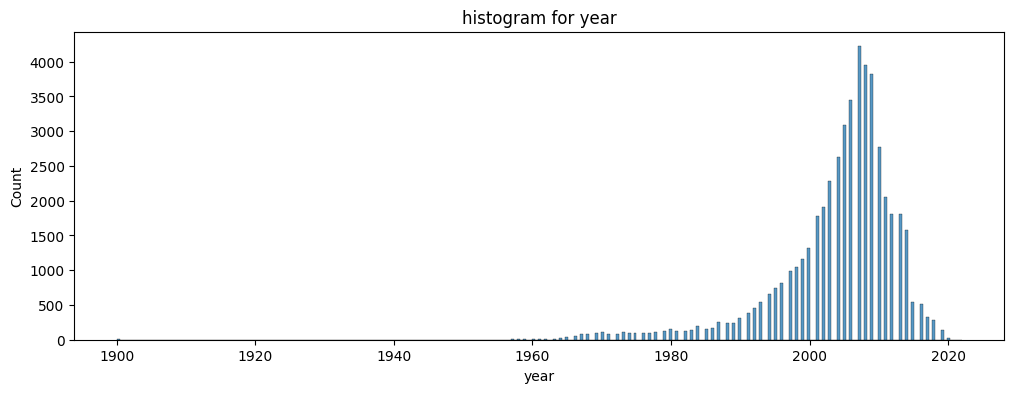

####################################################################################################
numerical analysis of duration_ms
statistical summary
count    5.067400e+04
mean     2.511536e+05
std      1.075892e+05
min      1.439000e+03
25%      1.927330e+05
50%      2.349330e+05
75%      2.881828e+05
max      3.816373e+06
Name: duration_ms, dtype: float64


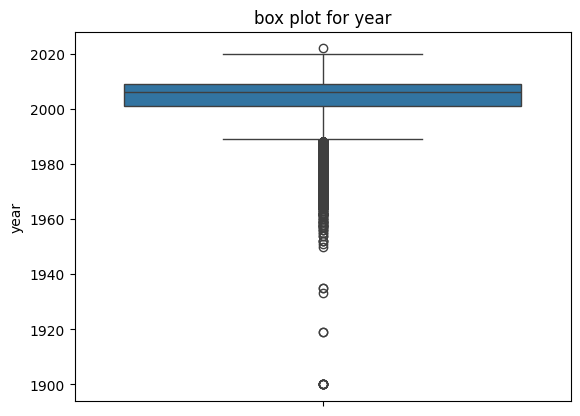

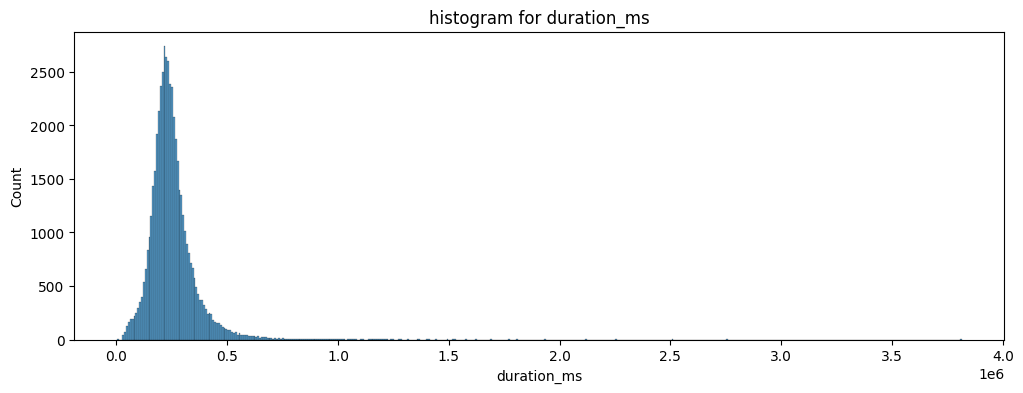

####################################################################################################
numerical analysis of key
statistical summary
count    50674.000000
mean         5.312507
std          3.567967
min          0.000000
25%          2.000000
50%          5.000000
75%          9.000000
max         11.000000
Name: key, dtype: float64


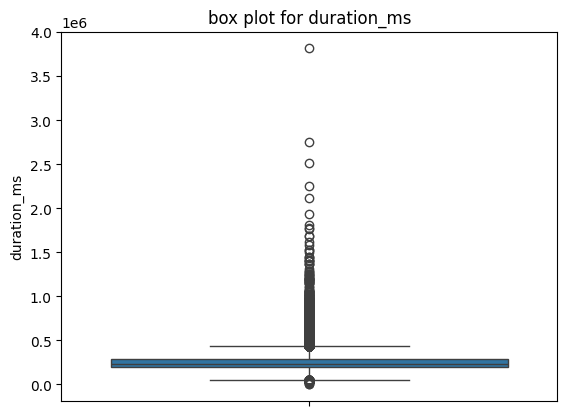

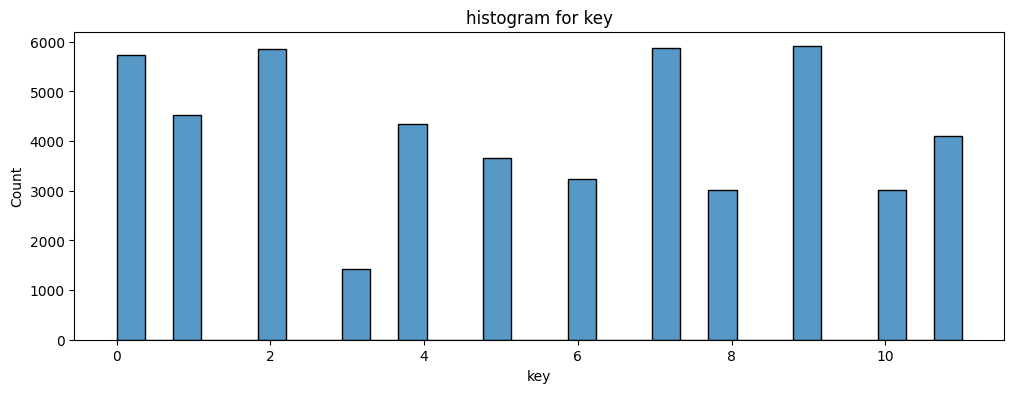

####################################################################################################
numerical analysis of mode
statistical summary
count    50674.000000
mean         0.631073
std          0.482519
min          0.000000
25%          0.000000
50%          1.000000
75%          1.000000
max          1.000000
Name: mode, dtype: float64


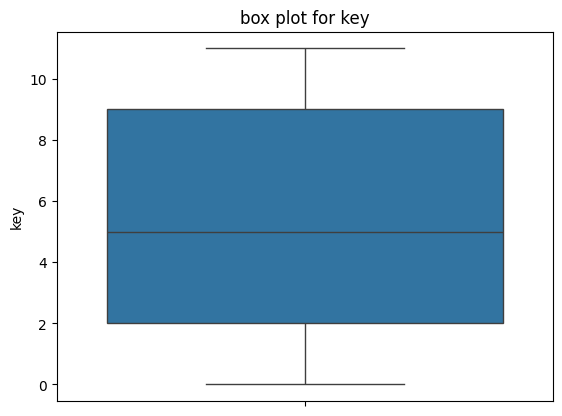

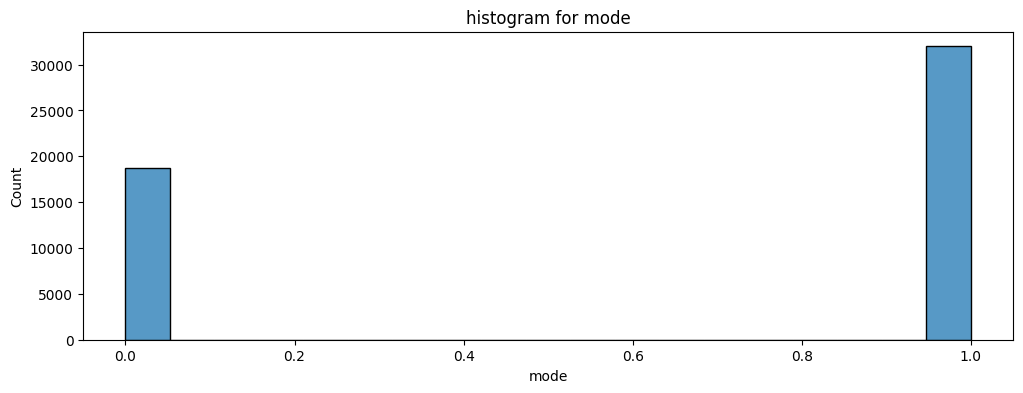

####################################################################################################
numerical analysis of time_signature
statistical summary
count    50674.000000
mean         3.898153
std          0.419686
min          0.000000
25%          4.000000
50%          4.000000
75%          4.000000
max          5.000000
Name: time_signature, dtype: float64


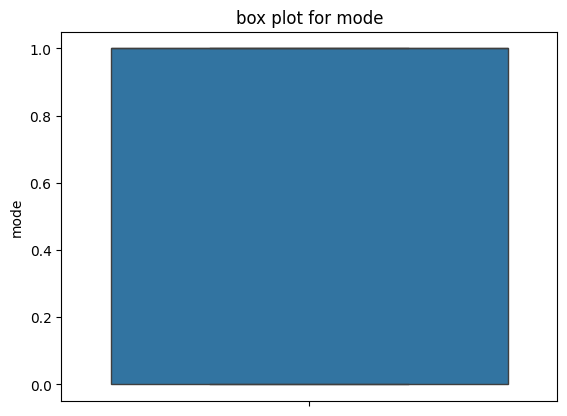

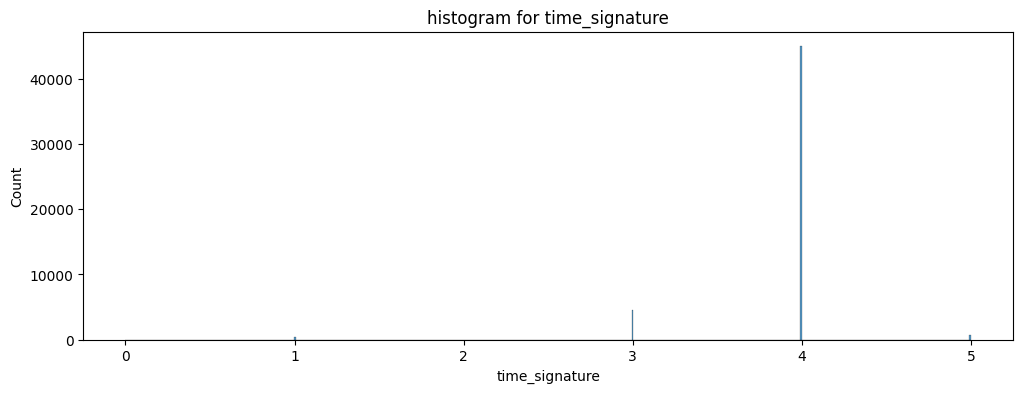

####################################################################################################
****************************************************************************************************
pair plot


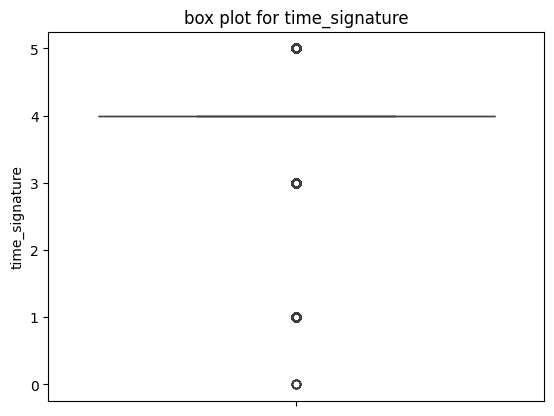

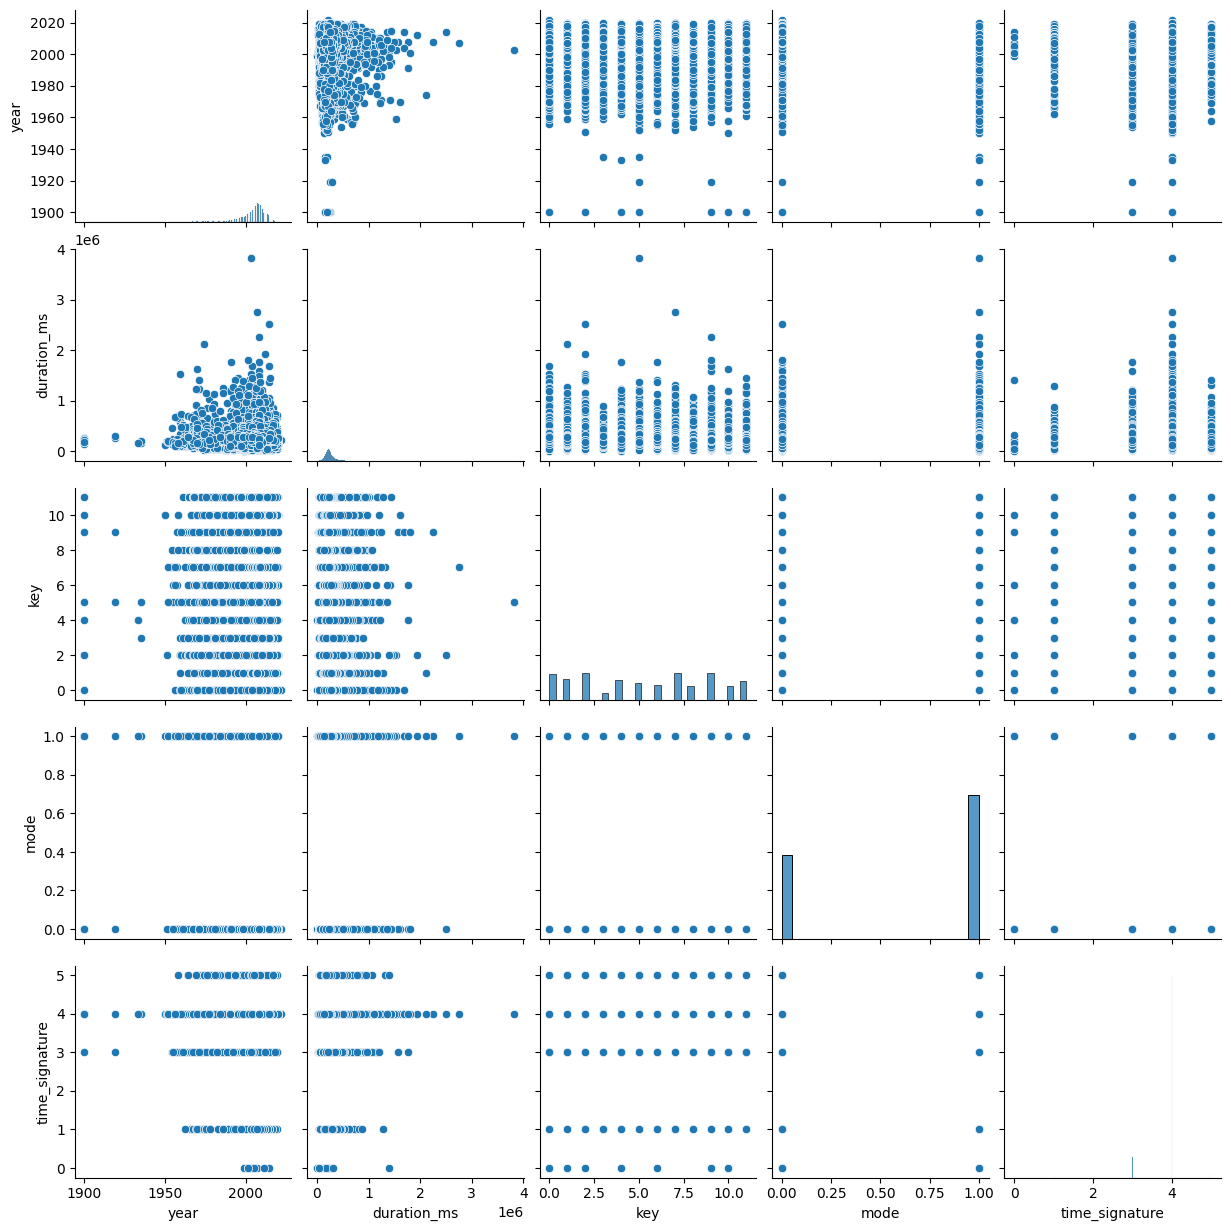

In [51]:
numerical_analysis(df , integer_col)

In [52]:
df2 = pd.read_csv('../data/user_listening_history.csv')

In [53]:
df2.head()

,track_id,user_id,playcount
0,TRIRLYL128F42539D1,b80344d063b5ccb3212f76538f3d9e43d87dca9e,1
1,TRFUPBA128F934F7E1,b80344d063b5ccb3212f76538f3d9e43d87dca9e,1
2,TRLQPQJ128F42AA94F,b80344d063b5ccb3212f76538f3d9e43d87dca9e,1
3,TRTUCUY128F92E1D24,b80344d063b5ccb3212f76538f3d9e43d87dca9e,1
4,TRHDDQG12903CB53EE,b80344d063b5ccb3212f76538f3d9e43d87dca9e,1


In [55]:
df2.isna().sum()

track_id     0
user_id      0
playcount    0
dtype: int64

In [57]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9711301 entries, 0 to 9711300
Data columns (total 3 columns):
 #   Column     Dtype 
---  ------     ----- 
 0   track_id   object
 1   user_id    object
 2   playcount  int64 
dtypes: int64(1), object(2)
memory usage: 222.3+ MB


In [59]:
df2.duplicated(subset = ['track_id','user_id']).sum()

np.int64(0)

In [61]:
df2.loc[:,'track_id'].nunique()

30459

In [62]:
### top 10 played songs

df2.loc[:,"track_id"].value_counts().head(10)

track_id
TRONYHY128F92C9D11    80656
TRUFTBY128F93450B8    39529
TRXWAZC128F9314B3E    30873
TRCPXID128F92D5D3C    30057
TRGCHLH12903CB7352    29708
TROMKCG128F9320C09    28735
TRPFYYL128F92F7144    28412
TRPGPDK12903CCC651    27276
TRWAQOC12903CB84CA    27222
TRAALAH128E078234A    26689
Name: count, dtype: int64

In [63]:
top_10_songs = df2.loc[:,"track_id"].value_counts().head(10)

In [64]:
top10_played_songs = df2.groupby('track_id')['playcount'].agg('sum').sort_values(ascending = False).head(10)

In [65]:
top10_played_songs

track_id
TRONYHY128F92C9D11    527893
TRUFTBY128F93450B8    111615
TRZNAHL128F9327D5A    111596
TRCPXID128F92D5D3C     91461
TRPGPDK12903CCC651     91448
TRXWAZC128F9314B3E     87745
TROMKCG128F9320C09     87050
TRPFYYL128F92F7144     85079
TRGCHLH12903CB7352     78443
TRAALAH128E078234A     76893
Name: playcount, dtype: int64